In [1]:
import os
import random
import warnings
from datetime import datetime
import gdown

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import squidpy as sq
from matplotlib import gridspec
from sklearn.preprocessing import MinMaxScaler

from nichecompass.models import NicheCompass
from nichecompass.utils import (add_gps_from_gp_dict_to_adata,
                                create_new_color_dict,
                                compute_communication_gp_network,
                                visualize_communication_gp_network,
                                extract_gp_dict_from_mebocost_es_interactions,
                                extract_gp_dict_from_nichenet_lrt_interactions,
                                extract_gp_dict_from_omnipath_lr_interactions,
                                filter_and_combine_gp_dict_gps,
                                generate_enriched_gp_info_plots)

In [2]:
import subprocess
from pathlib import Path
system = subprocess.check_output(["hostname", "-s"]).decode("utf-8").strip()
BASE_PATH_ = Path()
if "bun" in system:
    BASE_PATH_ = Path("/scratch/project_mnt/S0010/Xiao/Q1851/Xiao/")
elif "imb-quan-gpu" in system:
    BASE_PATH_ = Path("/home/uqxtan9/Q1851/Xiao/")


BASE_PATH = BASE_PATH_ / "Working_project/MB"
DATA_PATH = BASE_PATH / "Xenium_Brain"
XENIUM_RAW_PATH = DATA_PATH / "Xenium_RAW"
MALDI_RAW_PATH = DATA_PATH / "MALDI_RAW/imzml_file"
PROCESSED_ = Path("/scratch/project_mnt/S0010/Xiao/Q2051/Xiao/Working_project/MB/PROCESSED")
# PROCESSED_ = Path("/home/uqxtan9/Q2051/Xiao/Working_project/MB/PROCESSED")
PROCESSED_.mkdir(exist_ok=True, parents=True)
PROCESSED = BASE_PATH / "PROCESSED"
PROCESSED.mkdir(exist_ok=True, parents=True)
# OUT_PATH = Path("/home/uqxtan9/Q2051/Xiao/Working_project/MB/") / "PLOTS" / "Xenium"
OUT_PATH = Path("/scratch/project_mnt/S0010/Xiao/Q2051/Xiao/Working_project/MB/") / "PLOTS" / "Xenium"
OUT_PATH.mkdir(exist_ok=True, parents=True)
# OUT_PATH = BASE_PATH / "PLOTS" / "Xenium"
# OUT_PATH.mkdir(exist_ok=True, parents=True)
QC_PATH = OUT_PATH / "QC"
QC_PATH.mkdir(exist_ok=True, parents=True)
CLS_PATH = OUT_PATH / "CLUSTERING"
CLS_PATH.mkdir(exist_ok=True, parents=True)
CCI_PATH = OUT_PATH / "CCI"
CCI_PATH.mkdir(exist_ok=True, parents=True)
NICHE_PATH = OUT_PATH / "NICHE"
NICHE_PATH.mkdir(exist_ok=True, parents=True)

In [3]:
### Dataset ###
dataset = "MB"
species = "human"
batches = ["batch1", "batch2", "batch3"]
spatial_key = "spatial"
n_neighbors = 4

### Model ###
# AnnData keys
counts_key = "counts"
adj_key = "spatial_connectivities"
cat_covariates_keys = ["batch"]
gp_names_key = "nichecompass_gp_names"
active_gp_names_key = "nichecompass_active_gp_names"
gp_targets_mask_key = "nichecompass_gp_targets"
gp_targets_categories_mask_key = "nichecompass_gp_targets_categories"
gp_sources_mask_key = "nichecompass_gp_sources"
gp_sources_categories_mask_key = "nichecompass_gp_sources_categories"
latent_key = "nichecompass_latent"

# Architecture
cat_covariates_embeds_injection = ["gene_expr_decoder"]
cat_covariates_embeds_nums = [3]
cat_covariates_no_edges = [True]
conv_layer_encoder = "gcnconv"
active_gp_thresh_ratio = 0.01

# Trainer
n_epochs = 5
n_epochs_all_gps = 25
lr = 0.001
lambda_edge_recon = 500000.
lambda_gene_expr_recon = 300.
lambda_l1_masked = 0. # increase if gene selection desired
lambda_l1_addon = 100.
edge_batch_size = 1024*128 # increase if more memory available
n_sampled_neighbors = 4
use_cuda_if_available = True

### Analysis ###
cell_type_key = "cell_type"
latent_leiden_resolution = 0.2
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
sample_key = "batch"
spot_size = 2
differential_gp_test_results_key = "nichecompass_differential_gp_test_results"

In [4]:
# Get time of notebook execution for timestamping saved artifacts
now = datetime.now()
current_timestamp = now.strftime("%d%m%Y_%H%M%S")

In [5]:
# Define paths
ga_data_folder_path = "/scratch/project_mnt/S0010/Xiao/Q1851/Xiao/nichecompass/data/gene_annotations"
gp_data_folder_path = "/scratch/project_mnt/S0010/Xiao/Q1851/Xiao/nichecompass/data/gene_programs"
so_data_folder_path = "/scratch/project_mnt/S0010/Xiao/Q1851/Xiao/nichecompass/data/spatial_omics"
omnipath_lr_network_file_path = f"{gp_data_folder_path}/omnipath_lr_network.csv"
collectri_tf_network_file_path = f"{gp_data_folder_path}/collectri_tf_network_{species}.csv"
nichenet_lr_network_file_path = f"{gp_data_folder_path}/nichenet_lr_network_v2_{species}.csv"
nichenet_ligand_target_matrix_file_path = f"{gp_data_folder_path}/nichenet_ligand_target_matrix_v2_{species}.csv"
mebocost_enzyme_sensor_interactions_folder_path = f"{gp_data_folder_path}/metabolite_enzyme_sensor_gps"
gene_orthologs_mapping_file_path = f"{ga_data_folder_path}/human_mouse_gene_orthologs.csv"
artifacts_folder_path = f"./nichecompass/artifacts"
model_folder_path = f"{artifacts_folder_path}/sample_integration/{current_timestamp}/model"
figure_folder_path = f"{artifacts_folder_path}/sample_integration/{current_timestamp}/figures"

In [6]:
os.makedirs(model_folder_path, exist_ok=True)
os.makedirs(figure_folder_path, exist_ok=True)
os.makedirs(so_data_folder_path, exist_ok=True)

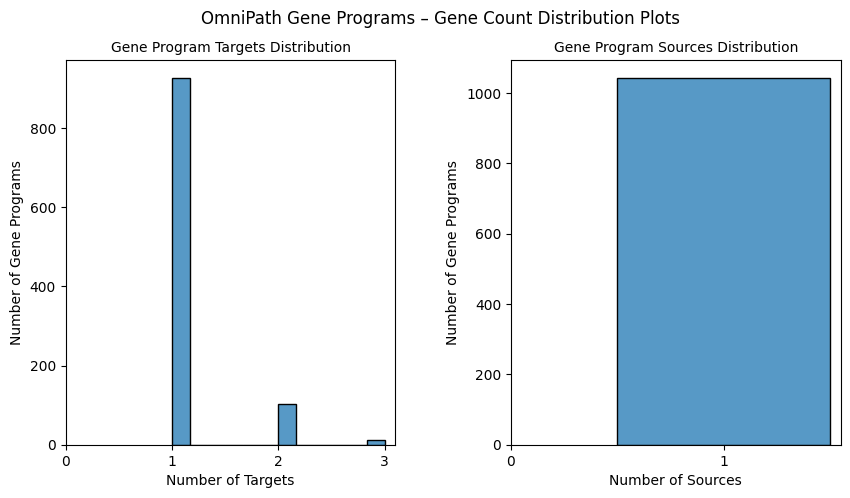

In [7]:
# Retrieve OmniPath GPs (source: ligand genes; target: receptor genes)
omnipath_gp_dict = extract_gp_dict_from_omnipath_lr_interactions(
    species=species,
    min_curation_effort=0,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=omnipath_lr_network_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True,
    gp_gene_count_distributions_save_path=f"{figure_folder_path}" \
                                           "/omnipath_gp_gene_count_distributions.svg")

In [8]:
# Display example OmniPath GP
omnipath_gp_names = list(omnipath_gp_dict.keys())
random.shuffle(omnipath_gp_names)
omnipath_gp_name = omnipath_gp_names[0]
print(f"{omnipath_gp_name}: {omnipath_gp_dict[omnipath_gp_name]}")

COMPLEX:DAGLA_ligand_receptor_GP: {'sources': ['COMPLEX:DAGLA'], 'targets': ['GPR55'], 'sources_categories': ['ligand'], 'targets_categories': ['receptor']}


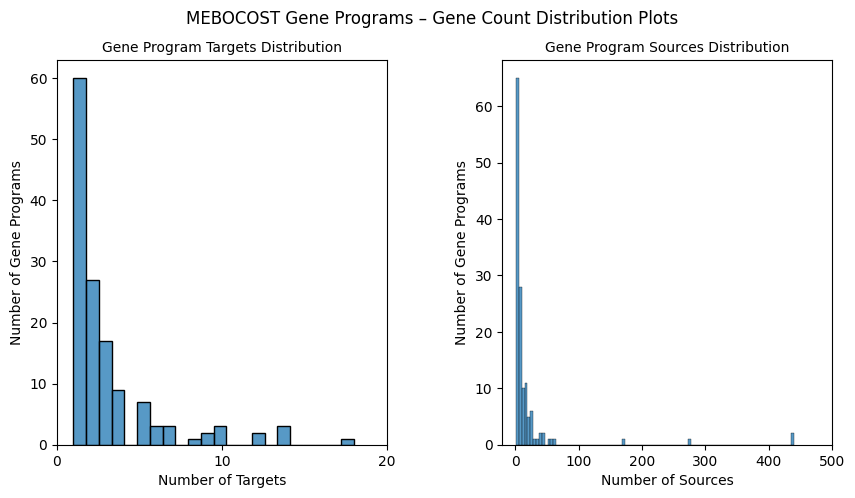

In [9]:
# Retrieve MEBOCOST GPs (source: enzyme genes; target: sensor genes)
mebocost_gp_dict = extract_gp_dict_from_mebocost_es_interactions(
    dir_path=mebocost_enzyme_sensor_interactions_folder_path,
    species=species,
    plot_gp_gene_count_distributions=True)

In [10]:
# Display example MEBOCOST GP
mebocost_gp_names = list(mebocost_gp_dict.keys())
random.shuffle(mebocost_gp_names)
mebocost_gp_name = mebocost_gp_names[0]
print(f"{mebocost_gp_name}: {mebocost_gp_dict[mebocost_gp_name]}")

D-Maltose_metabolite_enzyme_sensor_GP: {'sources': ['GAA', 'GANC', 'MGAM'], 'sources_categories': ['enzyme', 'enzyme', 'enzyme'], 'targets': ['SLC2A3'], 'targets_categories': ['sensor']}


/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/nichecompass/utils/gene_programs.py:496: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ligand_target_matrix_df.applymap(


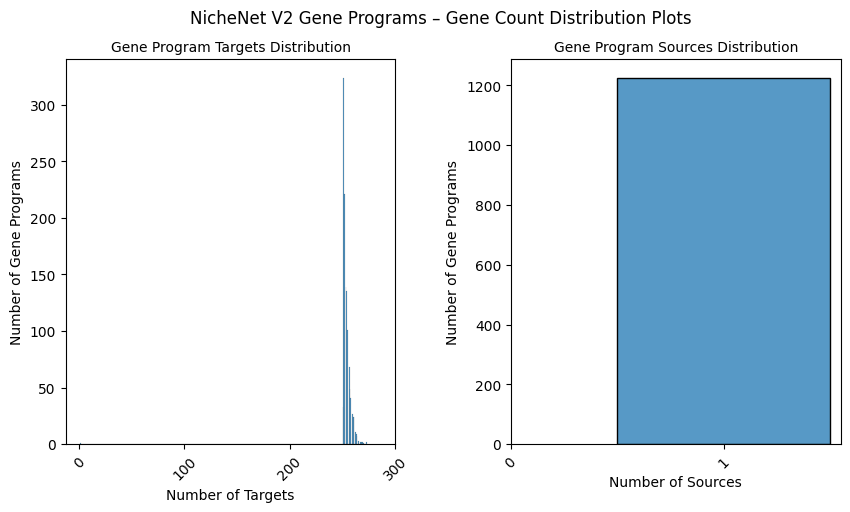

In [11]:
# Retrieve NicheNet GPs (source: ligand genes; target: receptor genes, target genes)
nichenet_gp_dict = extract_gp_dict_from_nichenet_lrt_interactions(
    species=species,
    version="v2",
    keep_target_genes_ratio=1.,
    max_n_target_genes_per_gp=250,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=nichenet_lr_network_file_path,
    ligand_target_matrix_file_path=nichenet_ligand_target_matrix_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True)

In [12]:
# Display example NicheNet GP
nichenet_gp_names = list(nichenet_gp_dict.keys())
random.shuffle(nichenet_gp_names)
nichenet_gp_name = nichenet_gp_names[0]
print(f"{nichenet_gp_name}: {nichenet_gp_dict[nichenet_gp_name]}")

DCHS1_ligand_receptor_target_gene_GP: {'sources': ['DCHS1'], 'targets': ['FAT4', 'ABCC6', 'ACYP1', 'ADM', 'AEBP1', 'AHNAK', 'ANGPTL4', 'ANKRD1', 'APP', 'AR', 'ARID1A', 'ASS1', 'ATF3', 'BAMBI', 'BAX', 'BBC3', 'BCL2', 'BCL2L1', 'BCL2L11', 'BCL3', 'BCL6', 'BDNF', 'BHLHE40', 'BIRC3', 'BIRC5', 'BMP4', 'BRCA1', 'BTG1', 'BTG2', 'CAV1', 'CBX5', 'CCL2', 'CCL5', 'CCN1', 'CCN2', 'CCNA2', 'CCNB1', 'CCND1', 'CCND2', 'CCND3', 'CD44', 'CDC6', 'CDH1', 'CDK1', 'CDK4', 'CDK6', 'CDKN1A', 'CDKN1B', 'CDKN2A', 'CDKN2C', 'CEBPA', 'CEBPB', 'CEMP1', 'CFLAR', 'CITED2', 'CKS1B', 'CSF2', 'CTNNB1', 'CXCL8', 'CXCR4', 'CYP1A1', 'CYP1B1', 'DDIT3', 'DDIT4', 'DDX46', 'DHRS3', 'DKK1', 'DTL', 'DUSP1', 'DUSP4', 'DUSP5', 'DUSP6', 'E2F1', 'EDN1', 'EFNA1', 'EGFR', 'EGR1', 'EGR2', 'EGR3', 'EIF5A', 'EMP1', 'ENO1', 'EPAS1', 'EPB41', 'EPHA2', 'ESR1', 'ETFB', 'FAS', 'FASN', 'FN1', 'FOS', 'FOSL1', 'FOSL2', 'FOXO3', 'FST', 'GADD45A', 'GADD45B', 'GADD45G', 'GAPDH', 'GATA3', 'GDF15', 'GJB5', 'GSN', 'GUCA2B', 'H2AC6', 'H2AX', 'H2BC21'

In [13]:
# Add GPs into one combined dictionary for model training
combined_gp_dict = dict(omnipath_gp_dict)
combined_gp_dict.update(mebocost_gp_dict)
combined_gp_dict.update(nichenet_gp_dict)

In [14]:
# Filter and combine GPs to avoid overlaps
combined_new_gp_dict = filter_and_combine_gp_dict_gps(
    gp_dict=combined_gp_dict,
    gp_filter_mode="subset",
    combine_overlap_gps=True,
    overlap_thresh_source_genes=0.9,
    overlap_thresh_target_genes=0.9,
    overlap_thresh_genes=0.9)

print("Number of gene programs before filtering and combining: "
      f"{len(combined_gp_dict)}.")
print(f"Number of gene programs after filtering and combining: "
      f"{len(combined_new_gp_dict)}.")

Number of gene programs before filtering and combining: 2406.
Number of gene programs after filtering and combining: 1987.


In [15]:
batches = [f.stem for f in XENIUM_RAW_PATH.iterdir() if f.is_dir()]
adata_batch_list = []

for batch in batches:
    print(f"Processing batch {batch}...")
    print("Loading data...")
    adata_batch = sc.read_h5ad(
        PROCESSED_ / f"{batch}_niche.h5ad")
    adata_batch.obs[sample_key] = batch
    print("Computing spatial neighborhood graph...\n")
    # Compute (separate) spatial neighborhood graphs
    sq.gr.spatial_neighbors(adata_batch,
                            coord_type="generic",
                            spatial_key=spatial_key,
                            n_neighs=n_neighbors)
    
    # Make adjacency matrix symmetric
    adata_batch.obsp[adj_key] = (
        adata_batch.obsp[adj_key].maximum(
            adata_batch.obsp[adj_key].T))
    adata_batch_list.append(adata_batch)
adata = ad.concat(adata_batch_list, join="inner")

# Combine spatial neighborhood graphs as disconnected components
batch_connectivities = []
len_before_batch = 0
for i in range(len(adata_batch_list)):
    if i == 0: # first batch
        after_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[0].shape[0],
            (adata.shape[0] -
            adata_batch_list[0].shape[0])))
        batch_connectivities.append(sp.hstack(
            (adata_batch_list[0].obsp[adj_key],
            after_batch_connectivities_extension)))
    elif i == (len(adata_batch_list) - 1): # last batch
        before_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[i].shape[0],
            (adata.shape[0] -
            adata_batch_list[i].shape[0])))
        batch_connectivities.append(sp.hstack(
            (before_batch_connectivities_extension,
            adata_batch_list[i].obsp[adj_key])))
    else: # middle batches
        before_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[i].shape[0], len_before_batch))
        after_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[i].shape[0],
            (adata.shape[0] -
            adata_batch_list[i].shape[0] -
            len_before_batch)))
        batch_connectivities.append(sp.hstack(
            (before_batch_connectivities_extension,
            adata_batch_list[i].obsp[adj_key],
            after_batch_connectivities_extension)))
    len_before_batch += adata_batch_list[i].shape[0]
adata.obsp[adj_key] = sp.vstack(batch_connectivities)

Processing batch P6055125...
Loading data...
Computing spatial neighborhood graph...

Processing batch P52407...
Loading data...
Computing spatial neighborhood graph...

Processing batch Ctrl_1...
Loading data...
Computing spatial neighborhood graph...

Processing batch Treated_1...
Loading data...
Computing spatial neighborhood graph...

Processing batch P38685...
Loading data...
Computing spatial neighborhood graph...

Processing batch Treated_2...
Loading data...
Computing spatial neighborhood graph...

Processing batch Ctrl_2...
Loading data...
Computing spatial neighborhood graph...

Processing batch B59460...
Loading data...
Computing spatial neighborhood graph...

Processing batch P62560...
Loading data...
Computing spatial neighborhood graph...



/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [16]:
# Add the GP dictionary as binary masks to the adata
add_gps_from_gp_dict_to_adata(
    gp_dict=combined_new_gp_dict,
    adata=adata,
    gp_targets_mask_key=gp_targets_mask_key,
    gp_targets_categories_mask_key=gp_targets_categories_mask_key,
    gp_sources_mask_key=gp_sources_mask_key,
    gp_sources_categories_mask_key=gp_sources_categories_mask_key,
    gp_names_key=gp_names_key,
    min_genes_per_gp=2,
    min_source_genes_per_gp=1,
    min_target_genes_per_gp=1,
    max_genes_per_gp=None,
    max_source_genes_per_gp=None,
    max_target_genes_per_gp=None)

In [17]:
cell_type_colors = create_new_color_dict(
    adata=adata,
    cat_key=cell_type_key)

In [18]:
samples = adata.obs[sample_key].unique().tolist()

In [19]:
# for sample in samples:
#     adata_batch = adata[adata.obs[sample_key] == sample]
    
#     print(f"Summary of sample {sample}:")
#     print(f"Number of nodes (observations): {adata_batch.layers[counts_key].shape[0]}")
#     print(f"Number of node features (genes): {adata_batch.layers[counts_key].shape[1]}")

#     # Visualize cell-level annotated data in physical space
#     sc.pl.spatial(adata_batch,
#                   color=cell_type_key,
#                   palette=cell_type_colors,
#                   spot_size=spot_size)

In [20]:
# Initialize model
model = NicheCompass(adata,
                     counts_key=counts_key,
                     adj_key=adj_key,
                     cat_covariates_embeds_injection=cat_covariates_embeds_injection,
                     cat_covariates_keys=cat_covariates_keys,
                     cat_covariates_no_edges=cat_covariates_no_edges,
                     cat_covariates_embeds_nums=cat_covariates_embeds_nums,
                     gp_names_key=gp_names_key,
                     active_gp_names_key=active_gp_names_key,
                     gp_targets_mask_key=gp_targets_mask_key,
                     gp_targets_categories_mask_key=gp_targets_categories_mask_key,
                     gp_sources_mask_key=gp_sources_mask_key,
                     gp_sources_categories_mask_key=gp_sources_categories_mask_key,
                     latent_key=latent_key,
                     conv_layer_encoder=conv_layer_encoder,
                     active_gp_thresh_ratio=active_gp_thresh_ratio)

--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
CATEGORICAL COVARIATES EMBEDDINGS INJECTION -> ['gene_expr_decoder']
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 266, n_cat_covariates_embed_input: 0, n_hidden: 164, n_latent: 64, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 64, n_addon_gp_input: 100, n_cat_covariates_embed_input: 3, n_output: 266
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 64, n_addon_gp_input: 100, n_cat_covariates_embed_input: 3, n_output: 266


In [21]:
# Train model
model.train(n_epochs=n_epochs,
            n_epochs_all_gps=n_epochs_all_gps,
            lr=lr,
            lambda_edge_recon=lambda_edge_recon,
            lambda_gene_expr_recon=lambda_gene_expr_recon,
            lambda_l1_masked=lambda_l1_masked,
            edge_batch_size=edge_batch_size,
            n_sampled_neighbors=n_sampled_neighbors,
            use_cuda_if_available=use_cuda_if_available,
            verbose=False)


--- INITIALIZING TRAINER ---
Number of training nodes: 3288789
Number of validation nodes: 365421
Number of training edges: 7552481
Number of validation edges: 839164
Edge batch size: 131072
Node batch size: None


/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/torch_geometric/sampler/neighbor_sampler.py:55: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  warnings.warn(f"The usage of the 'directed' argument in "



--- MODEL TRAINING ---
Epoch 1/5 |████----------------| 20.0% train_global_loss: 162588.3432; train_optim_loss: 162588.3432; val_global_loss: 164750.9286; val_optim_loss: 164750.9286
Epoch 2/5 |████████------------| 40.0% train_global_loss: 149733.7974; train_optim_loss: 149733.7974; val_global_loss: 149402.3438; val_optim_loss: 149402.3438
Epoch 3/5 |████████████--------| 60.0% train_global_loss: 141220.1794; train_optim_loss: 141220.1794; val_global_loss: 140709.8571; val_optim_loss: 140709.8571
Epoch 4/5 |████████████████----| 80.0% train_global_loss: 135978.8852; train_optim_loss: 135978.8852; val_global_loss: 138186.0737; val_optim_loss: 138186.0737
Epoch 5/5 |████████████████████| 100.0% train_global_loss: 133365.4189; train_optim_loss: 133365.4189; val_global_loss: 136081.5893; val_optim_loss: 136081.5893

Model training finished after 22 min 12 sec.
Using best model state, which was in epoch 5.

--- MODEL EVALUATION ---
val AUROC score: 0.8071
val AUPRC score: 0.9609
val best 

/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/torch_geometric/sampler/neighbor_sampler.py:55: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  warnings.warn(f"The usage of the 'directed' argument in "


: 

In [22]:
# Compute latent neighbor graph
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)

# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [ ]:
# Save trained model
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata.h5ad")

In [ ]:
# load_timestamp = "10022024_082855"
load_timestamp = current_timestamp # uncomment if you trained the model in this notebook

figure_folder_path = f"{artifacts_folder_path}/sample_integration/{load_timestamp}/figures"
model_folder_path = f"{artifacts_folder_path}/sample_integration/{load_timestamp}/model"

os.makedirs(figure_folder_path, exist_ok=True)

In [ ]:
# # Load trained model
# model = NicheCompass.load(dir_path=model_folder_path,
#                           adata=None,
#                           adata_file_name="adata.h5ad",
#                           gp_names_key=gp_names_key)

In [ ]:
samples = model.adata.obs[sample_key].unique().tolist()

In [ ]:
batch_colors = create_new_color_dict(
    adata=model.adata,
    cat_key=cat_covariates_keys[0])
cell_type_colors = create_new_color_dict(
    adata=model.adata,
    cat_key=cell_type_key)


/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "

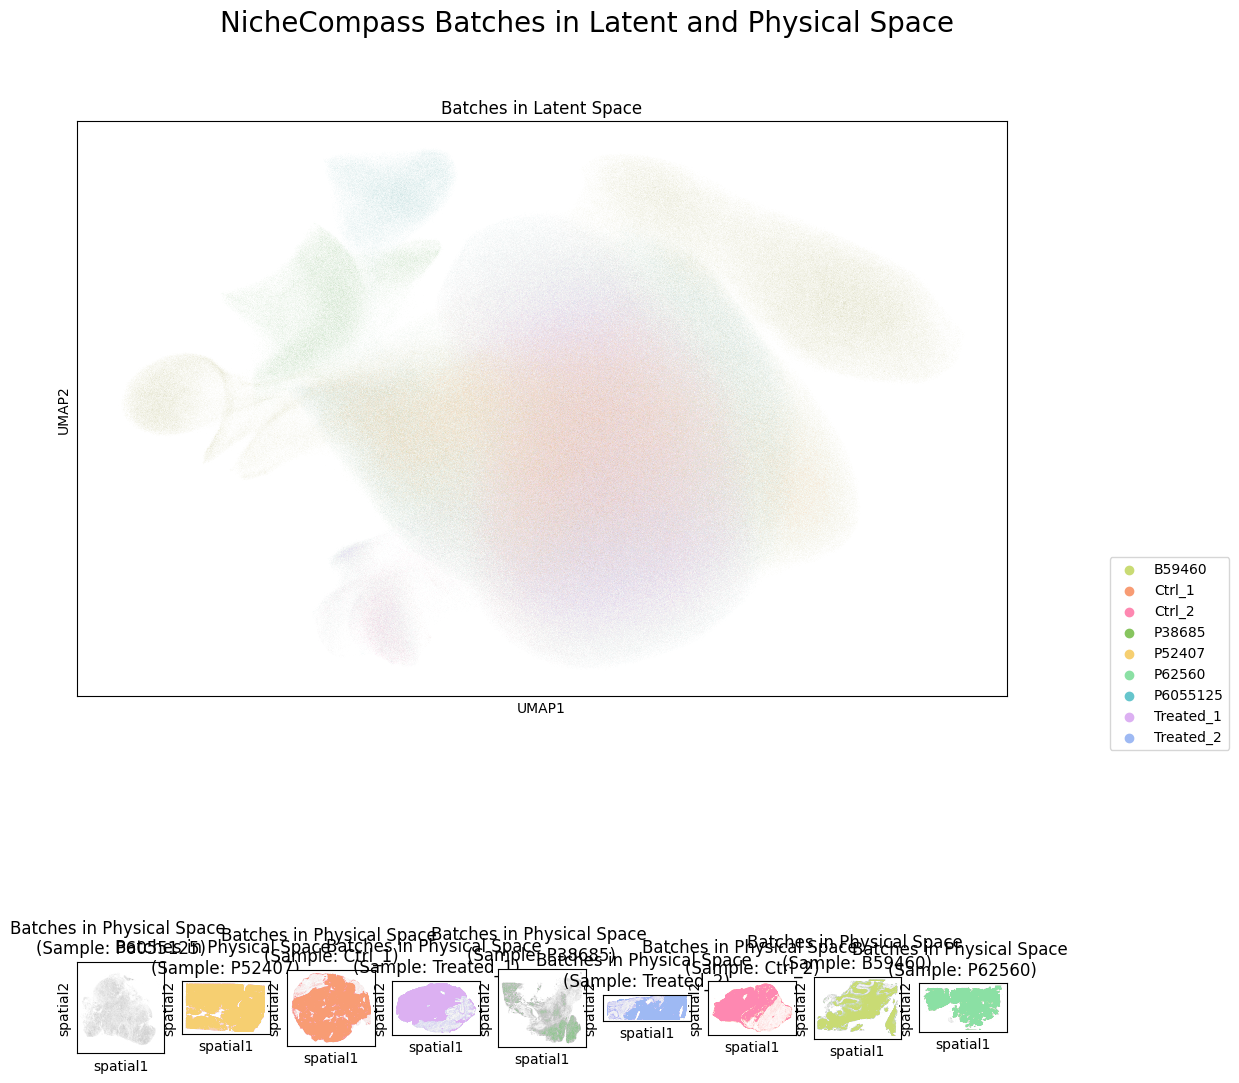

In [ ]:
# Create plot of batch annotations in physical and latent space
groups = None
save_fig = True
file_path = f"{figure_folder_path}/" \
            "batches_latent_physical_space.svg"

fig = plt.figure(figsize=(12, 4*len(samples)))
title = fig.suptitle(t=f"NicheCompass Batches " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=1,
                          nrows=len(samples),
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata,
           color=[cat_covariates_keys[0]],
           groups=groups,
           palette=batch_colors,
           title=f"Batches in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=[cat_covariates_keys[0]],
                  groups=groups,
                  palette=batch_colors,
                  spot_size=spot_size,
                  title=f"Batches in Physical Space \n"
                        f"(Sample: {sample})",
                  legend_loc=None,
                  ax=axs[idx+1],
                  show=False)

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight")
plt.show()

/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/uqxtan9/micromamba/envs/nicecompass/lib/python3.9/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "

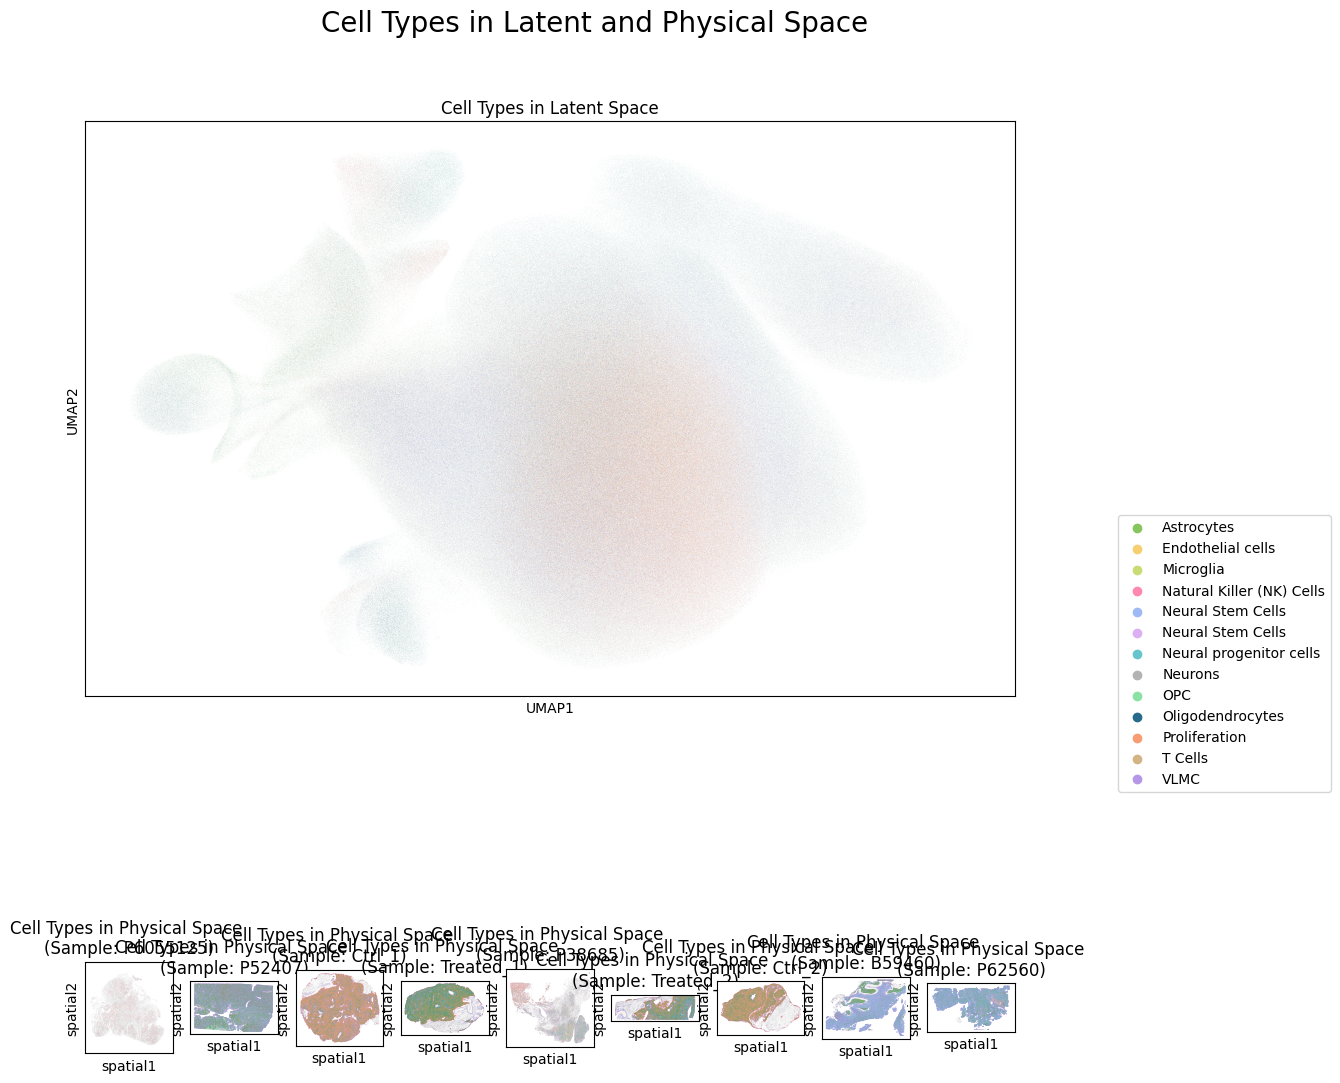

In [ ]:
# Create plot of cell type annotations in physical and latent space
groups = None
save_fig = True
file_path = f"{figure_folder_path}/" \
            "cell_types_latent_physical_space.svg"

fig = plt.figure(figsize=(12, 14))
title = fig.suptitle(t=f"Cell Types " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=len(samples),
                          nrows=2,
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata,
           color=[cell_type_key],
           groups=groups,palette=cell_type_colors,
           title=f"Cell Types in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=[cell_type_key],
                  groups=groups,
                  palette=cell_type_colors,
                  spot_size=spot_size,
                  title=f"Cell Types in Physical Space \n"
                        f"(Sample: {sample})",
                  legend_loc=None,
                  ax=axs[idx+1],
                  show=False)

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight")
plt.show()

In [ ]:
# Compute latent Leiden clustering
sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)

/tmp/ipykernel_2065723/3143097019.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata=model.adata,


In [ ]:
latent_cluster_colors = create_new_color_dict(
    adata=model.adata,
    cat_key=latent_cluster_key)

In [ ]:
# Create plot of latent cluster / niche annotations in physical and latent space
groups = None # set this to a specific cluster for easy visualization, e.g. ["0"]
save_fig = True
file_path = f"{figure_folder_path}/" \
            f"res_{latent_leiden_resolution}_" \
            "niches_latent_physical_space.svg"

fig = plt.figure(figsize=(12, 14))
title = fig.suptitle(t=f"NicheCompass Niches " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=len(samples),
                          nrows=2,
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata,
           color=[latent_cluster_key],
           groups=groups,
           palette=latent_cluster_colors,
           title=f"Niches in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=[latent_cluster_key],
                  groups=groups,
                  palette=latent_cluster_colors,
                  spot_size=spot_size,
                  title=f"Niches in Physical Space \n"
                        f"(Sample: {sample})",
                  legend_loc=None,
                  ax=axs[idx+1],
                  show=False)

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight")
plt.show()

In [ ]:
save_fig = True
file_path = f"{figure_folder_path}/" \
            f"res_{latent_leiden_resolution}_" \
            f"niche_composition_batches.svg"

df_counts = (model.adata.obs.groupby([latent_cluster_key, cat_covariates_keys[0]])
             .size().unstack())
df_counts.plot(kind="bar", stacked=True, figsize=(10,10))
legend = plt.legend(bbox_to_anchor=(1, 1), loc="upper left", prop={'size': 10})
legend.set_title("Batch Annotations", prop={'size': 10})
plt.title("Batch Composition of Niches")
plt.xlabel("Niche")
plt.ylabel("Cell Counts")
if save_fig:
    plt.savefig(file_path,
                bbox_extra_artists=(legend,),
                bbox_inches="tight")

In [ ]:
save_fig = True
file_path = f"{figure_folder_path}/" \
            f"res_{latent_leiden_resolution}_" \
            f"niche_composition_cell_types.svg"

df_counts = (model.adata.obs.groupby([latent_cluster_key, cell_type_key])
             .size().unstack())
df_counts.plot(kind="bar", stacked=True, figsize=(10,10))
legend = plt.legend(bbox_to_anchor=(1, 1), loc="upper left", prop={'size': 10})
legend.set_title("Cell Type Annotations", prop={'size': 10})
plt.title("Cell Type Composition of Niches")
plt.xlabel("Niche")
plt.ylabel("Cell Counts")
if save_fig:
    plt.savefig(file_path,
                bbox_extra_artists=(legend,),
                bbox_inches="tight")

In [ ]:
# Save trained model
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata.h5ad")